# L6b: Let's build a classical Hopfield Network Classifier
IN this lab, we'll extend our disucssion of Hopfield Networks to build a classical Hopfield Network Classifier. 

> __Learning Objectives:__
> 
> By the end of this lab, you should be able to:
> Three learning objectives go here

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Environment Setup__
>
> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Implementations
The notebook uses functions for Hopfield network operations:

> * `decode(s; number_of_rows, number_of_columns)`: Converts a flattened state vector $\mathbf{s}$ back to an $n \times n$ image matrix. This local function (defined below) reshapes the vector, transposes it to match row-major ordering, and replaces $-1$ values with $0$ for grayscale display.

In [2]:
function decode(s::Vector{<: Number}; number_of_rows::Int=28, number_of_columns::Int=28)::Array{<: Number,2}

    # reconstructed image -
    X = reshape(s, number_of_rows, number_of_columns) |> X -> transpose(X) |> Matrix;
    X̂ = replace(X, -1 => 0);
    
    # return -
    return X̂
end;

### Constants
Before we dive into the data, let's set up some constants that we'll use throughout the notebook. See the comment next to the constant value for more information, e.g., permissible values, units, etc.

In [ ]:
number_of_rows = 16; # number of rows in the image
number_of_cols = 16; # number of cols in the image
ϕ = 0.58; # fraction of maximum capacity of the Hopfield Network that we want to use (change this)
number_of_pixels = number_of_rows*number_of_cols; # how many pixels do we have in the image?
KMAX = 0.138*number_of_pixels |> x-> round(x, RoundDown); # maximum capacity of the Hopfield Network (see lecture slides for more details)
number_of_images_to_memorize = Int(ϕ*KMAX |> x-> round(x, RoundDown)); # TODO: number of images that we want to encode (change this)

In [4]:
println("Max number of images that we can encode in the Hopfield Network: ", KMAX)
println("Number of images that we will encode in the Hopfield Network: ", number_of_images_to_memorize)

Max number of images that we can encode in the Hopfield Network: 35.0
Number of images that we will encode in the Hopfield Network: 19


### Data
Fill me in

In [5]:
originaldataset = MyUSPSHandwrittenDigitImageDataset(); # load the original dataset records as a NamedTuple (features) labels (targets)

Let's look at a few of these images:

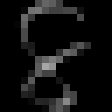

What is the label for this image? 8


In [6]:
let 
    
    # initialize -
    image_index_to_decode = 101;
    s = originaldataset.records[image_index_to_decode];
    label = originaldataset.labels[image_index_to_decode];
    X̂ = decode(s, number_of_rows = number_of_rows, number_of_columns = number_of_cols);

    # print -
    println("What is the label for this image? ", label);

    # show the image -
    Gray.(X̂) |> display
end

Next, let's build a training set of images that we want to memorize in our Hopfield Network. We will use the `number_of_images_to_memorize` variable to control how many images we want to encode in our network. The balance of images can then be used as a test set to evaluate the performance of our network.

> __How are we going to do this?__
>
> We need to load examples of each digit (0-9) into our training set. We can use the `number_digit_array` variable to control which digits we want to include in our training set. For example, if we set `number_digit_array = [0, 1, 2]`, then we will only include images of the digits 0, 1, and 2 in our training set. Alternatively, if we set `number_digit_array = range(0, length=10, step=1) |> collect`, then we will include images of all digits (0-9) in our training set.

In this example, let's include multiple copies of each digit in our training set to increase the number of images we can memorize in our network. We'll save the image feature vectors as a collection stored in the `training_dataset::Array{Int32,2}` variable, and their corresponding labels in the `training_labels::Array{Int32,1}` variable.

In [7]:
training_dataset, training_labels, training_source_indices = let

    # initialize -
    features = originaldataset.records; # image feature vectors stored as rows in this matrix
    labels = originaldataset.labels; # image labels stored as a vector
    number_of_training_images = Int(number_of_images_to_memorize);
    training_dataset = Array{Int32,2}(undef, number_of_pixels, number_of_training_images); # image feature vectors stored as columns in this matrix
    training_labels = Array{Int32,1}(undef, number_of_training_images); # image labels stored as a vector
    training_source_indices = Array{Int32,1}(undef, number_of_training_images); # source indices used to construct training set
    number_digit_array = range(0,length=10,step=1) |> collect; # numbers 0 ... 9

    # build the training dataset -
    # pre-compute and randomize indices for each digit label -
    digit_to_indices = Dict(digit => shuffle!(findall(==(digit), labels)) for digit ∈ number_digit_array);
    digit_to_cursor = Dict(digit => 1 for digit ∈ number_digit_array);

    # cycle 0,1,2,...,9,0,1,2,... until we hit capacity -
    for image_counter ∈ 1:number_of_training_images
        digit = number_digit_array[mod1(image_counter, length(number_digit_array))];
        index_pool = digit_to_indices[digit];
        cursor = digit_to_cursor[digit];

        # if we exhausted this digit pool, reshuffle and reuse -
        if cursor > length(index_pool)
            shuffle!(index_pool);
            cursor = 1;
        end

        image_index = index_pool[cursor];
        digit_to_cursor[digit] = cursor + 1;
        training_dataset[:, image_counter] = Int32.(ifelse.(features[image_index] .>= 0.0, 1, -1));
        training_labels[image_counter] = Int32(labels[image_index]);
        training_source_indices[image_counter] = Int32(image_index);
    end

    # return -
    training_dataset, training_labels, training_source_indices;
end

(Int32[-1 -1 … -1 -1; -1 -1 … -1 -1; … ; -1 -1 … -1 -1; -1 -1 … -1 -1], Int32[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8], Int32[920, 4260, 6885, 5805, 4245, 2824, 6244, 1373, 101, 372, 6467, 1987, 5866, 6205, 3083, 2090, 3220, 2080, 1662])

Let's grab a training image and visualize it to make sure everything looks good:

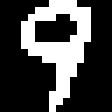

What is the label for this image? 9


In [17]:
let

    # initialize -
    training_image_to_decode = 10;
    s = training_dataset[:, training_image_to_decode];
    label = training_labels[training_image_to_decode];
    X̂ = decode(s, number_of_rows = number_of_rows, number_of_columns = number_of_cols);

    # print -
    println("What is the label for this image? ", label);

    # show the image -
    Gray.(X̂) |> display
end

How balanced are we? Let's check the labels and see what our training distribution looks like:

In [9]:
let
    
    # check the balance of the training labels -
    number_digit_array = range(0,length=10,step=1) |> collect; # numbers 0 ... 9
    label_counts = Dict(digit => count(==(digit), training_labels) for digit ∈ number_digit_array); # Wow! Super fancy one-liner to count the number of occurrences of each digit label in the training set!
    println("Training label distribution: ", label_counts);
end

Training label distribution: Dict(0 => 2, 4 => 2, 5 => 2, 6 => 2, 2 => 2, 7 => 2, 9 => 1, 8 => 2, 3 => 2, 1 => 2)


Compute and print the training-memory correlation matrix.


In [34]:
let

    # Correlation between stored training memories (columns of training_dataset)
    X = Float64.(training_dataset);
    sample_correlation = cor(X, dims=1) |> Matrix;
end

20×20 Matrix{Float64}:
  1.0        -0.0102788   0.14031     …   0.0679928    0.0203327
 -0.0102788   1.0         0.0851888       0.346812     0.1537
  0.14031     0.0851888   1.0             0.00506682  -0.00312262
  0.26238     0.0049637  -0.177173        0.0130369    0.244807
  0.0254877   0.070793    0.00472415      0.0580596    0.37623
  0.321722    0.224539    0.0341725   …   0.117859     0.190669
  0.0914638   0.14637     0.303084        0.00223134   0.0283423
  0.0459314   0.0735042  -0.228174        0.130889     0.340771
  0.0049142   0.726878    0.123448        0.37483      0.237871
  0.0344558   0.365687    0.107595        0.326697     0.548887
  0.733149    0.0414583   0.174315    …  -0.00222812   0.0846557
 -0.0554412   0.76628     0.0993351       0.396707     0.250387
 -0.0175507   0.122906    0.307451        0.0954808    0.117881
  0.288775    0.140939   -0.12997         0.0863197    0.12013
  0.114407   -0.0617575   0.211804        0.014598    -0.0147068
  0.496365    0

Build a test dataset.

In [11]:
test_dataset, test_labels, test_source_indices = let

    # initialize -
    features = originaldataset.records;
    labels = originaldataset.labels;
    number_digit_array = range(0,length=10,step=1) |> collect; # numbers 0 ... 9
    requested_number_of_test_images = Int(number_of_images_to_memorize); # change this if you want a different test-set size
    used_training_indices = Set(Int.(training_source_indices)); # never reuse training images
    available_digit_indices = Dict(
        digit => shuffle!(filter(idx -> !(idx ∈ used_training_indices), findall(==(digit), labels)))
        for digit ∈ number_digit_array
    );
    digit_to_cursor = Dict(digit => 1 for digit ∈ number_digit_array);

    # cycle 0,1,2,...,9,0,1,2,... until we hit the requested test-set size -
    selected_indices = Int[];
    image_counter = 1;
    while length(selected_indices) < requested_number_of_test_images
        digit = number_digit_array[mod1(image_counter, length(number_digit_array))];
        index_pool = available_digit_indices[digit];
        cursor = digit_to_cursor[digit];

        # stop if we run out of unseen images for a required digit in the cycle -
        if cursor > length(index_pool)
            println("Stopped early at ", length(selected_indices), " test images: no more unseen examples for digit ", digit, ".");
            break;
        end

        image_index = index_pool[cursor];
        push!(selected_indices, image_index);
        digit_to_cursor[digit] = cursor + 1;
        image_counter += 1;
    end

    number_of_test_images = length(selected_indices);
    test_dataset = Array{Int32,2}(undef, number_of_pixels, number_of_test_images);
    test_labels = Array{Int32,1}(undef, number_of_test_images);
    test_source_indices = Array{Int32,1}(undef, number_of_test_images);

    for j ∈ 1:number_of_test_images
        image_index = selected_indices[j];
        test_dataset[:, j] = Int32.(ifelse.(features[image_index] .>= 0.0, 1, -1));
        test_labels[j] = Int32(labels[image_index]);
        test_source_indices[j] = Int32(image_index);
    end

    @assert isempty(intersect(Set(Int.(test_source_indices)), used_training_indices)) "Test set overlaps with training set.";

    test_dataset, test_labels, test_source_indices;
end

(Int32[-1 -1 … -1 -1; -1 -1 … -1 -1; … ; -1 -1 … -1 -1; -1 -1 … -1 -1], Int32[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8], Int32[4333, 282, 4269, 3143, 3683, 4216, 2248, 2138, 1427, 1483, 5020, 4643, 5059, 104, 5324, 2483, 3244, 5415, 913])

___

## Task 1: Classical Hopfield Network Classifier with Hebbian Learning
In this task, we'll implement a classical Hopfield Network Classifier using Hebbian learning, i.e., we'll use the data to compute the weights of the Hopfield Network and then use the network to classify new images.

Now that we have the training images let's encode the model. We'll compute the weights and the bias term and store them [in an instance of the `MyClassicalHopfieldNetworkModel` type](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/hopfield/#VLDataScienceMachineLearningPackage.MyClassicalHopfieldNetworkModel). The weights are stored in the `W` field, and the bias term is stored in the `b` field. 

> __How do we build this model__? We build the model (and estimate the weight matrix and bias vector) using [the `build(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/factory/). This method takes the type of thing we want to construct, namely [a `MyClassicalHopfieldNetworkModel` instance](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/hopfield/#VLDataScienceMachineLearningPackage.MyClassicalHopfieldNetworkModel), and the memories we want to encode. The (vectorized) memories are stored in the columns of an array. The [`build(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/factory/) returns a model instance with the `W` and `b` fields populated.

Let's store the encoded model in the `model::MyClassicalHopfieldNetworkModel` variable.

In [12]:
model = build(MyClassicalHopfieldNetworkModel, (
    memories = training_dataset, # load the training images as the memories to encode in the Hopfield Network
));

Now, let's give the model a memory and see if it can recall it. We'll look at examples of various difficulties, e.g., a clean memory, a noisy memory, and a completely random input of a digit in the test set (never seen by the model before). Let's start with a clean memory. 

> __How do we recall a memory?__ We can use the [`recall(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/hopfield/#VLDataScienceMachineLearningPackage.recall) to recall a memory from the model. This method takes the model instance, an input state vector, and some optional parameters that control the recall process. The method returns the recalled state vector, the energy of the recalled state, and the number of iterations it took to converge.

In [13]:
(f₁,e₁, s, s₁, label) = let

    # initialize -
    memory_to_recall = rand(1:size(training_dataset, 2)); # change this to select a different memory to recall from the training set
    θ = 0.90; # fraction of pixels that we want to keep correct during the recall process (change this)

    #=
    # Case 1: Give the model a clean memory to recall -
    label = training_labels[memory_to_recall];
    # true_image_energy = -Inf32; # we can set this to -Inf if we want the recall process to be controlled by maxiterations/patience rather than early-stopping on this threshold
    true_image_energy = model.energy[memory_to_recall]; # Give the true energy if we want to use early-stopping based on this threshold
    s₁ = training_dataset[:, memory_to_recall]; # true memory we want to recall
    s = training_dataset[:, memory_to_recall]; # initial state for the recall process (in this case, we give the model the clean memory as the initial state)
    =#

    
    
    # Case 2: Give the model a noisy memory to recall -
    label = training_labels[memory_to_recall];
    # true_image_energy = model.energy[memory_to_recall] |> Float32; # we can use a fraction of the true energy if we want to make it easier for the recall process to succeed (i.e. easier early-stopping based on this threshold)
    true_image_energy = -Inf32; # we can set this to -Inf if we want the recall process to be controlled by maxiterations/patience rather than early-stopping on this threshold
    s₁ = training_dataset[:, memory_to_recall]; # true memory we want to recall
    s = copy(s₁); # initial state for the recall process

    # cut 1 - θ fraction of the pixels, replace with - 1
    number_of_pixels_to_corrupt = round(Int, (1 - θ)*number_of_pixels);
    start =(number_of_pixels - number_of_pixels_to_corrupt) + 1;
    for i ∈ start:number_of_pixels
        s[i] = -1;
    end

    #=
    # Case 3: Pull a random image from the test set (never seen by the model before) and give it to the model to recall -
    random_test_image_index = rand(1:size(test_dataset, 2));
    label = test_labels[random_test_image_index];
    s₁ = test_dataset[:, random_test_image_index]; # held-out test image (not used during training)
    s = copy(s₁); # initial state for the recall process
    true_image_energy = -Inf32; # unknown for test images; use -Inf so recall is controlled by maxiterations/patience, not early-stop on this threshold
    println("Min Hamming (random test input vs training set) = ", minimum(hamming(s₁, training_dataset[:, i]) for i ∈ 1:size(training_dataset, 2)))
    =#

    # run the recall process -
    frames, energydictionary = recover(model, s, true_image_energy, maxiterations=1000*number_of_pixels, 
        patience = number_of_pixels);

    # get the recovered image -
    ks = collect(keys(energydictionary))
    best_key = argmin(k -> energydictionary[k], ks)
    best_state = frames[best_key]

    # print some data for this recall process -
    println("Hamming (best recovered memory vs true memory) = ", hamming(best_state, s₁))
    println("Hamming (best recovered memory vs initial memory) = ", hamming(best_state, s))

    # return the frames -
    (frames, energydictionary,s, s₁, label)
end;

┌ Info: Initial state exactly matches stored memory index = 3. Stopping.
└ @ VLDataScienceMachineLearningPackage /Users/jdv27/.julia/packages/VLDataScienceMachineLearningPackage/d50ED/src/Hopfield.jl:86


Hamming (best recovered memory vs true memory) = 0
Hamming (best recovered memory vs initial memory) = 0


In [14]:
f₁

Dict{Int64, Vector{Int32}} with 1 entry:
  0 => [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1  …  -1, -1, -1, -1, -1, -1, -1, …

Which image does the model recover? The code block below displays the true image (top), the corrupted initial image (middle), and the recovered image (bottom).

> __Check:__ 
> 
> To evaluate the quality of the recovered image, we can compute the Hamming distance between the recovered state and the true image. The Hamming distance quantifies the number of differing pixels, providing a measure of retrieval accuracy. A lower Hamming distance indicates a closer match to the original image. If the Hamming distance is zero, it means the recovered image exactly matches the true image.
> 
> We check if the Hamming distance between the recovered image and the true image is less than the Hamming distance between the corrupted image and the true image. If it is, no error is thrown; otherwise, an error is raised indicating that the recovery was unsuccessful.

So what do we get?

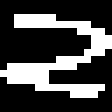

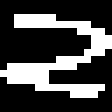

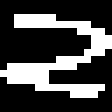

The label for the image we tried to recall was: 2


In [15]:
let

    # initialize -
    frames = f₁;
    energydictionary = e₁;
    
    # get the initial image -
    initial_image = decode(s, number_of_rows = number_of_rows, number_of_columns = number_of_cols);
    true_image = decode(s₁, number_of_rows = number_of_rows, number_of_columns = number_of_cols);
    
    # Get the best recovered image -
    ks = collect(keys(energydictionary))
    best_key = argmin(k -> energydictionary[k], ks)
    best_state = frames[best_key]
    recovered_image = decode(best_state, number_of_rows = number_of_rows, number_of_columns = number_of_cols);

    # what was the label for the image we tried to recall? -
    println("The label for the image we tried to recall was: ", label);

    # Show the images -
    Gray.(true_image) |> display;
    Gray.(initial_image) |> display;
    Gray.(recovered_image) |> display;
end;

__What about the label?__ We can also check the label of the recovered image to see if it matches the true label. The label of the recovered image is determined by finding the closest memory in the model's memories to the recovered state vector. We can compute the Hamming distance between the recovered state vector and each of the memories in the model, and then find the memory with the smallest Hamming distance. The label of that memory is then assigned as the predicted label for the recovered image.

In [16]:
let

    # initialize -
    frames = f₁;
    energydictionary = e₁;

    # get the recovered memory
    best_key = collect(keys(energydictionary)) |> ks -> argmin(k -> energydictionary[k], ks)
    best_state = frames[best_key]

    #  ok, so need to find the closest training image to this recovered memory -
    hamming_distances = [hamming(best_state, training_dataset[:, i]) for i ∈ 1:size(training_dataset, 2)];
    closest_training_image_index = argmin(hamming_distances);
    closest_training_image_label = training_labels[closest_training_image_index];

    # what is the label of the closest training image to the recovered memory?
    println("The label of the closest training image to the recovered memory is: ", closest_training_image_label);
end

The label of the closest training image to the recovered memory is: 2


## Task 2: Classical Hopfield Network Classifier with Pseudo-Inverse Learning
In this task, we'll implement a classical Hopfield Network Classifier using Pseudo-Inverse learning, i.e., we'll use the data to compute the weights of the Hopfield Network using the pseudo-inverse method and then use the network to classify new images.

## Summary
One direct, concise summary sentence goes here

> __Key Takeaways:__
> 
> Three key takeaways go here

One direct concluding setence goes here
___